In [4]:
import pandas as pd
import pydicom as pyd
import SimpleITK as sitk
import matplotlib.pyplot as plt
import glob
import os
import sys
import shutil
sys.path.insert(0, "/Users/mohamedyousif/Development/knee-landmarks-xray")

from src.segmentation.predict import predict_batch

round = 2

os.chdir("/Users/mohamedyousif/Development/knee-landmarks-xray/")
image_metadata_path = "../../../../../Volumes/HDD_02/datasets/emory_mrkr/tables/MRKR_lateral_image_metadata.csv"
out_path = f"experiments/segmentations/round_{round}/unlabeled_subset.csv"

df = pd.read_csv(image_metadata_path)

if  os.path.exists(out_path):
    subset = pd.read_csv(out_path)
else:
    
    subset = df[(df["is_segmented"] == False) & (df["arthroplasty"] == '0')].sample(50, random_state=42)
    subset.to_csv(out_path, index=False)


In [2]:

predict_batch(
    checkpoint_path=f"experiments/segmentations/round_{round}/checkpoints/unet_resnet34_v2_best.pt",
    csv_path=f"experiments/segmentations/round_{round}/unlabeled_subset.csv",
    data_dir=f"../../../../../Volumes/HDD_02/datasets/emory_mrkr/images",
    output_dir=f"experiments/segmentations/round_{round}/predictions",
)


100%|██████████| 50/50 [00:48<00:00,  1.02it/s]


In [7]:
revised_mask_paths = glob.glob(f"experiments/segmentations/round_{round}/revisions/*.nrrd")

for idx, mask_path in enumerate(revised_mask_paths):
    row_bool = subset.mask_path.apply(os.path.basename) == os.path.basename(mask_path)
    row = subset[row_bool]

    mpath_hdd = row['mask_path'].iloc[0]
    os.makedirs(os.path.dirname(mpath_hdd), exist_ok=True)
    shutil.copy2(mask_path, mpath_hdd)

    df.loc[row.index, 'is_segmented'] = True


df.to_csv(image_metadata_path, index=False)
    

In [32]:
df.iloc[18,:]

empi_anon                                                          10009152
StudyInstanceUID_anon       1.2.841.113978.3.61.1.63957911.20210432.1115113
SeriesInstanceUID_anon         1.2.840.113564.102371819.2021042811405971836
SOPInstanceUID_anon       1.2.826.0.1.3680043.8.498.11394860332101057443...
img_height                                                           3020.0
img_width                                                            2400.0
laterality                                                                L
view_position                                                             L
horizontal_flip                                                         0.0
weight_bearing                                                          1.0
inverted                                                                  1
arthroplasty                                                              0
L_KLG_inference                                                         NaN
R_KLG_infere

In [33]:
print(subset['mask_path'].isna().sum())
print(subset['mask_path'].iloc[0])


0
/Volumes/HDD_02/datasets/emory_mrkr/masks/36074155/1.2.826.0.1.3680043.8.498.10932057035107690439494348438173460050.nrrd


In [34]:
print(glob.glob(f"experiments/segmentations/round_2/revisions/*.nrrd")[:3])
print(subset['mask_path'].apply(os.path.basename).iloc[:3].tolist())


['experiments/segmentations/round_2/revisions/1.2.826.0.1.3680043.8.498.25076315427544901726304478257155397372.nrrd', 'experiments/segmentations/round_2/revisions/1.2.826.0.1.3680043.8.498.22994680039748916056452165264935685978.nrrd', 'experiments/segmentations/round_2/revisions/1.2.826.0.1.3680043.8.498.52720171110988782706142298120812577135.nrrd']
['1.2.826.0.1.3680043.8.498.10932057035107690439494348438173460050.nrrd', '1.2.826.0.1.3680043.8.498.39035238074935404231668909057896700337.nrrd', '1.2.826.0.1.3680043.8.498.13313885792322544941650703285415641466.nrrd']


In [29]:
row

,empi_anon,StudyInstanceUID_anon,SeriesInstanceUID_anon,SOPInstanceUID_anon,img_height,img_width,laterality,view_position,horizontal_flip,weight_bearing,...,L_KLG_inference,R_KLG_inference,SeriesDescription,StudyDescription,StudyDate_anon,age_at_exam,dicom_path,is_arthroplasty,mask_path,is_segmented
18,66222077,1.2.842.113977.3.57.1.56529930.20180230.1111347,1.2.849.113623.2.209.4.2147483648.1519319880.2...,1.2.826.0.1.3680043.8.498.35845235463347465195...,1643.0,1087.0,R,L,0.0,0.0,...,NaN,NaN,Knee,XR KNEE 3 VIEWS BILATERAL,2017-12-23,58,66222077/1.2.842.113977.3.57.1.56529930.201802...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/6622...,False


In [36]:
for mask_path in revised_mask_paths:
    row_bool = df['mask_path'].apply(lambda x: os.path.basename(str(x))) == os.path.basename(mask_path)
    row = df[row_bool]

    if row.empty:
        print(f"No match found for {os.path.basename(mask_path)}")
        continue

    mpath_hdd = row['mask_path'].iloc[0]
    os.makedirs(os.path.dirname(mpath_hdd), exist_ok=True)
    shutil.copy2(mask_path, mpath_hdd)
    df.loc[row.index, 'is_segmented'] = True
    print(f"Copied: {os.path.basename(mask_path)}")

df.to_csv(image_metadata_path, index=False)


Copied: 1.2.826.0.1.3680043.8.498.25076315427544901726304478257155397372.nrrd
Copied: 1.2.826.0.1.3680043.8.498.22994680039748916056452165264935685978.nrrd
Copied: 1.2.826.0.1.3680043.8.498.52720171110988782706142298120812577135.nrrd
Copied: 1.2.826.0.1.3680043.8.498.14715376837191903651508373392035934938.nrrd
Copied: 1.2.826.0.1.3680043.8.498.67431327436203263527070685328842117750.nrrd
Copied: 1.2.826.0.1.3680043.8.498.45128874801967730290945324561960911731.nrrd
Copied: 1.2.826.0.1.3680043.8.498.13313885792322544941650703285415641466.nrrd
Copied: 1.2.826.0.1.3680043.8.498.98963462006372841198150295730432967998.nrrd
Copied: 1.2.826.0.1.3680043.8.498.10950119216935385748099214790539831245.nrrd
Copied: 1.2.826.0.1.3680043.8.498.71385985867370247206178471176394805382.nrrd
Copied: 1.2.826.0.1.3680043.8.498.64817314336929424645423004250674538068.nrrd
Copied: 1.2.826.0.1.3680043.8.498.10782390501064940516136747184600413226.nrrd
Copied: 1.2.826.0.1.3680043.8.498.307934290449741424136464717795

In [28]:
for mask_path in revised_mask_paths:
    row_bool = subset.mask_path.apply(os.path.basename) == os.path.basename(mask_path)
    row = subset[row_bool]

    if row.empty:
        print(f"No match found for {os.path.basename(mask_path)}")
        continue

    mpath_hdd = row['mask_path'].iloc[0]

    print(os.path.exists(mask_path))
    print(os.path.exists(mpath_hdd))

    # os.makedirs(os.path.dirname(mpath_hdd), exist_ok=True)


    # shutil.copy2(mask_path, mpath_hdd)
    # df.loc[row.index, 'is_segmented'] = True
    print(f"Copied: {os.path.basename(mask_path)}")


True
True
Copied: 1.2.826.0.1.3680043.8.498.25076315427544901726304478257155397372.nrrd
True
True
Copied: 1.2.826.0.1.3680043.8.498.22994680039748916056452165264935685978.nrrd
True
True
Copied: 1.2.826.0.1.3680043.8.498.52720171110988782706142298120812577135.nrrd
True
True
Copied: 1.2.826.0.1.3680043.8.498.14715376837191903651508373392035934938.nrrd
True
True
Copied: 1.2.826.0.1.3680043.8.498.67431327436203263527070685328842117750.nrrd
True
True
Copied: 1.2.826.0.1.3680043.8.498.45128874801967730290945324561960911731.nrrd
True
True
Copied: 1.2.826.0.1.3680043.8.498.13313885792322544941650703285415641466.nrrd
True
True
Copied: 1.2.826.0.1.3680043.8.498.98963462006372841198150295730432967998.nrrd
True
True
Copied: 1.2.826.0.1.3680043.8.498.10950119216935385748099214790539831245.nrrd
True
True
Copied: 1.2.826.0.1.3680043.8.498.71385985867370247206178471176394805382.nrrd
True
True
Copied: 1.2.826.0.1.3680043.8.498.64817314336929424645423004250674538068.nrrd
True
True
Copied: 1.2.826.0.1.36

In [21]:

df.to_csv(image_metadata_path, index=False)

In [24]:
segmented_df = df[df.is_segmented == True]

In [25]:
missing = [row['mask_path'] for _, row in segmented_df.iterrows() if not os.path.exists(row['mask_path'])]
print(len(missing))


29


In [26]:
df.loc[df['mask_path'].isin(missing), 'is_segmented'] = False
# df.loc[df['mask_path'].isin(missing), 'mask_path'] = None
df.to_csv(image_metadata_path, index=False)
print(f"Marked {len(missing)} rows as unsegmented")


Marked 29 rows as unsegmented


In [27]:
df[df.is_segmented == True]

,empi_anon,StudyInstanceUID_anon,SeriesInstanceUID_anon,SOPInstanceUID_anon,img_height,img_width,laterality,view_position,horizontal_flip,weight_bearing,...,L_KLG_inference,R_KLG_inference,SeriesDescription,StudyDescription,StudyDate_anon,age_at_exam,dicom_path,is_arthroplasty,mask_path,is_segmented
0,10001182,1.2.849.113972.3.57.1.62631357.20201023.1122916,1.2.840.113570.163246170217.20201019125748437223,1.2.826.0.1.3680043.8.498.40281381358579896373...,2539.0,2079.0,R,L,0.0,1.0,...,NaN,NaN,LATERAL,XR Knee 3 Views Right Standard Protocol,2020-05-24,62,10001182/1.2.849.113972.3.57.1.62631357.202010...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,True
1,10001758,1.2.840.113975.3.59.1.64324621.20210625.1133227,1.2.842.113572.163246212233.20210618135511646926,1.2.826.0.1.3680043.8.498.73756677603175613024...,2589.0,1820.0,R,L,0.0,0.0,...,NaN,NaN,Lateral,XR Knee 3 Views Right Standard Protocol,2021-08-06,41,10001758/1.2.840.113975.3.59.1.64324621.202106...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,True
5,10005139,1.2.847.113971.3.58.1.64088247.20210525.1111318,1.2.846.113569.102371823.2021051711115742165,1.2.826.0.1.3680043.8.498.34442268881085133569...,3020.0,2400.0,R,L,0.0,1.0,...,NaN,NaN,LAT WGHT BEARING,XR KNEE 4 VIEWS BILATERAL,2021-01-24,53,10005139/1.2.847.113971.3.58.1.64088247.202105...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,True
7,10005857,1.2.845.113975.3.58.1.55294874.20170725.1100340,1.2.842.113569.163246173245.20170720100502547950,1.2.826.0.1.3680043.8.498.40241314153378422961...,2230.0,2258.0,L,L,0.0,0.0,...,NaN,NaN,LATERAL,XR KNEE 1 OR 2 VIEWS LEFT,2017-05-12,50,10005857/1.2.845.113975.3.58.1.55294874.201707...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,True
10,10006398,1.2.842.113974.3.66.1.52978627.20160518.1153906,1.2.840.113572.1632466918.20160513153658515735,1.2.826.0.1.3680043.8.498.18490008618876512919...,2539.0,2201.0,R,L,0.0,0.0,...,NaN,NaN,SUNRISE,XR KNEE 3 VIEWS BILATERAL,2016-09-03,89,10006398/1.2.842.113974.3.66.1.52978627.201605...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,True
13,10007041,1.2.840.113972.3.66.1.55342946.20170736.1145051,1.2.847.113568.1632466951.201707281455219221,1.2.826.0.1.3680043.8.498.72682748722282075159...,2544.0,1512.0,L,L,0.0,1.0,...,NaN,NaN,LAT WGHT BEARING,XR KNEE 3 VIEWS BILATERAL,2017-04-05,32,10007041/1.2.840.113972.3.66.1.55342946.201707...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,True
15,10008355,1.2.843.113973.3.61.1.62121163.20200809.1082410,1.2.840.113567.163246170218.20200804142741609154,1.2.826.0.1.3680043.8.498.87627891745080363845...,2539.0,3050.0,R,L,0.0,0.0,...,NaN,NaN,LATERAL,XR KNEE 1 OR 2 VIEWS RIGHT,2021-01-17,59,10008355/1.2.843.113973.3.61.1.62121163.202008...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,True
17,10008929,1.2.844.113974.3.61.1.56893349.20180425.1220202,1.2.844.113627.2.208.4.2147483653.1524536596.9...,1.2.826.0.1.3680043.8.498.59865667543833718880...,1624.0,1288.0,R,L,0.0,0.0,...,NaN,NaN,Knee,XR Knee 3 Views Right Standard Protocol,2017-12-12,40,10008929/1.2.844.113974.3.61.1.56893349.201804...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,True
18,10009152,1.2.841.113978.3.61.1.63957911.20210432.1115113,1.2.840.113564.102371819.2021042811405971836,1.2.826.0.1.3680043.8.498.11394860332101057443...,3020.0,2400.0,L,L,0.0,1.0,...,NaN,NaN,LAT WGHT BEARING,XR KNEE 4 VIEWS LEFT,2021-08-06,66,10009152/1.2.841.113978.3.61.1.63957911.202104...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,True
21,10009890,1.2.846.113978.3.58.1.53742609.20161013.1132236,1.2.841.113571.1632466926.20161007123018921758,1.2.826.0.1.3680043.8.498.82299289423640415347...,2544.0,1821.0,R,L,0.0,0.0,...,NaN,NaN,LATERAL,XR KNEE 1 OR 2 VIEWS RIGHT,2016-08-03,20,10009890/1.2.846.113978.3.58.1.53742609.201610...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,True


In [14]:
os.path.exists(subset["mask_path"].iloc[0])

True

In [6]:
revised_mask_paths

['experiments/segmentations/round_2/revisions/1.2.826.0.1.3680043.8.498.25076315427544901726304478257155397372.nrrd',
 'experiments/segmentations/round_2/revisions/1.2.826.0.1.3680043.8.498.22994680039748916056452165264935685978.nrrd',
 'experiments/segmentations/round_2/revisions/1.2.826.0.1.3680043.8.498.52720171110988782706142298120812577135.nrrd',
 'experiments/segmentations/round_2/revisions/1.2.826.0.1.3680043.8.498.14715376837191903651508373392035934938.nrrd',
 'experiments/segmentations/round_2/revisions/1.2.826.0.1.3680043.8.498.67431327436203263527070685328842117750.nrrd',
 'experiments/segmentations/round_2/revisions/1.2.826.0.1.3680043.8.498.45128874801967730290945324561960911731.nrrd',
 'experiments/segmentations/round_2/revisions/1.2.826.0.1.3680043.8.498.13313885792322544941650703285415641466.nrrd',
 'experiments/segmentations/round_2/revisions/1.2.826.0.1.3680043.8.498.98963462006372841198150295730432967998.nrrd',
 'experiments/segmentations/round_2/revisions/1.2.826.0.

In [50]:
import glob
import os
import pydicom as pyd
import SimpleITK as sitk
import matplotlib.pyplot as plt



In [3]:
os.chdir("/Users/mohamedyousif/Development/knee-landmarks-xray/")
dcm_paths = glob.glob(f'experiments/segmentations/round_{round}/predictions/*.dcm')
mask_paths = [p.replace('.dcm','.nrrd') for p in dcm_paths]

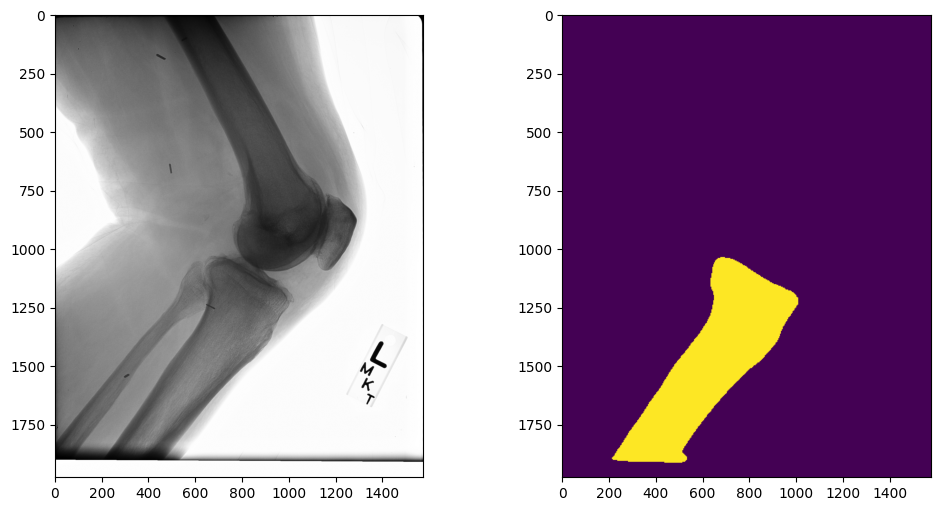

In [11]:
idx=3

testimg = pyd.dcmread(dcm_paths[idx]).pixel_array
testmask_read = sitk.ReadImage(mask_paths[idx])
testmask = sitk.GetArrayFromImage(testmask_read)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(testimg, 'gray')
ax2.imshow(testmask.squeeze(0))

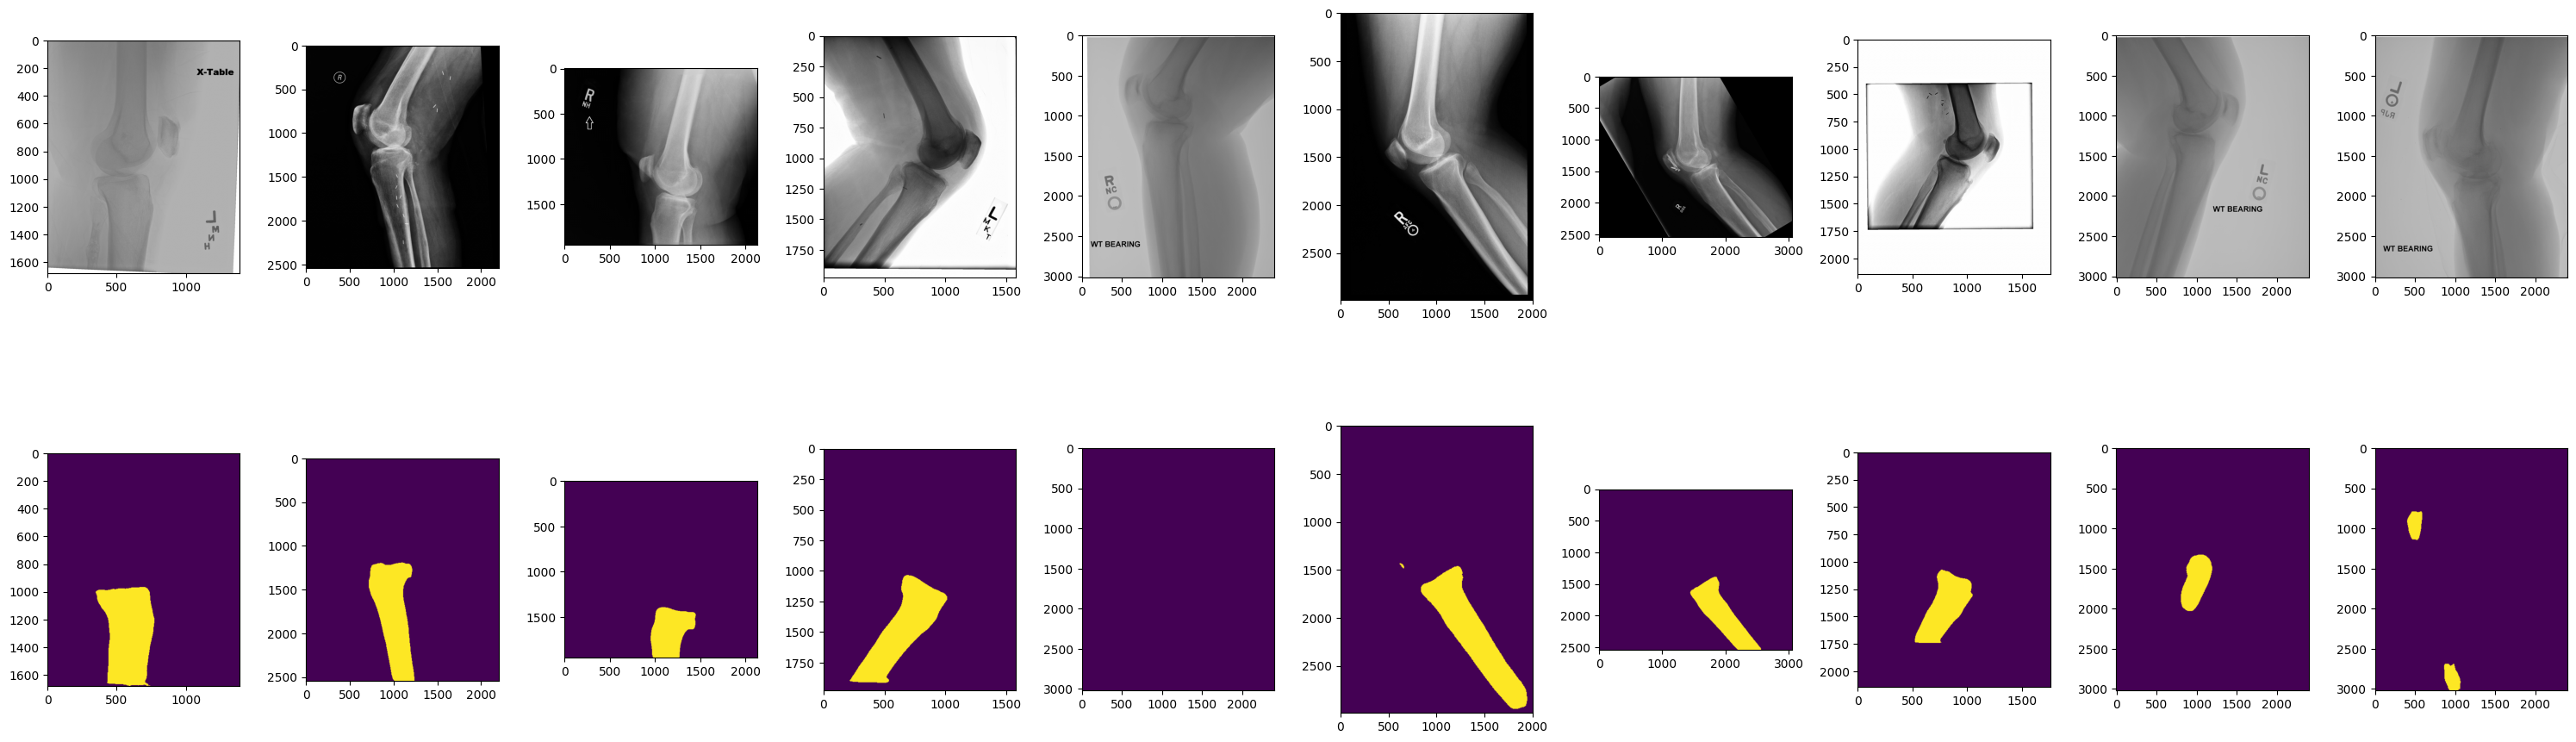

In [43]:
idx1, idx2 = 0, 10

r = range(idx1, idx2)

fig, ax = plt.subplots(2,len(r), figsize=(30, 10))

# print(list(r))
# print(ax)

for row, idx in enumerate(r):

    testimg = pyd.dcmread(dcm_paths[idx]).pixel_array
    testmask_read = sitk.ReadImage(mask_paths[idx])
    testmask = sitk.GetArrayFromImage(testmask_read)

    # print(idx)

    ax[0][row].imshow(testimg, 'gray')
    ax[1][row].imshow(testmask.squeeze(0))

plt.tight_layout()

In [ ]:
axes[2].imshow(testimg, 'gray')
axes[2].imshow(testmask.squeeze(0), alpha=0.2, cmap='Reds')
axes[2].set_title('Overlay')

In [47]:
len(dcm_paths)

50

In [ ]:
round((len(dcm_paths) / 5))

TypeError: 'int' object is not callable

In [53]:
round(len(dcm_paths) / 5)

TypeError: 'int' object is not callable

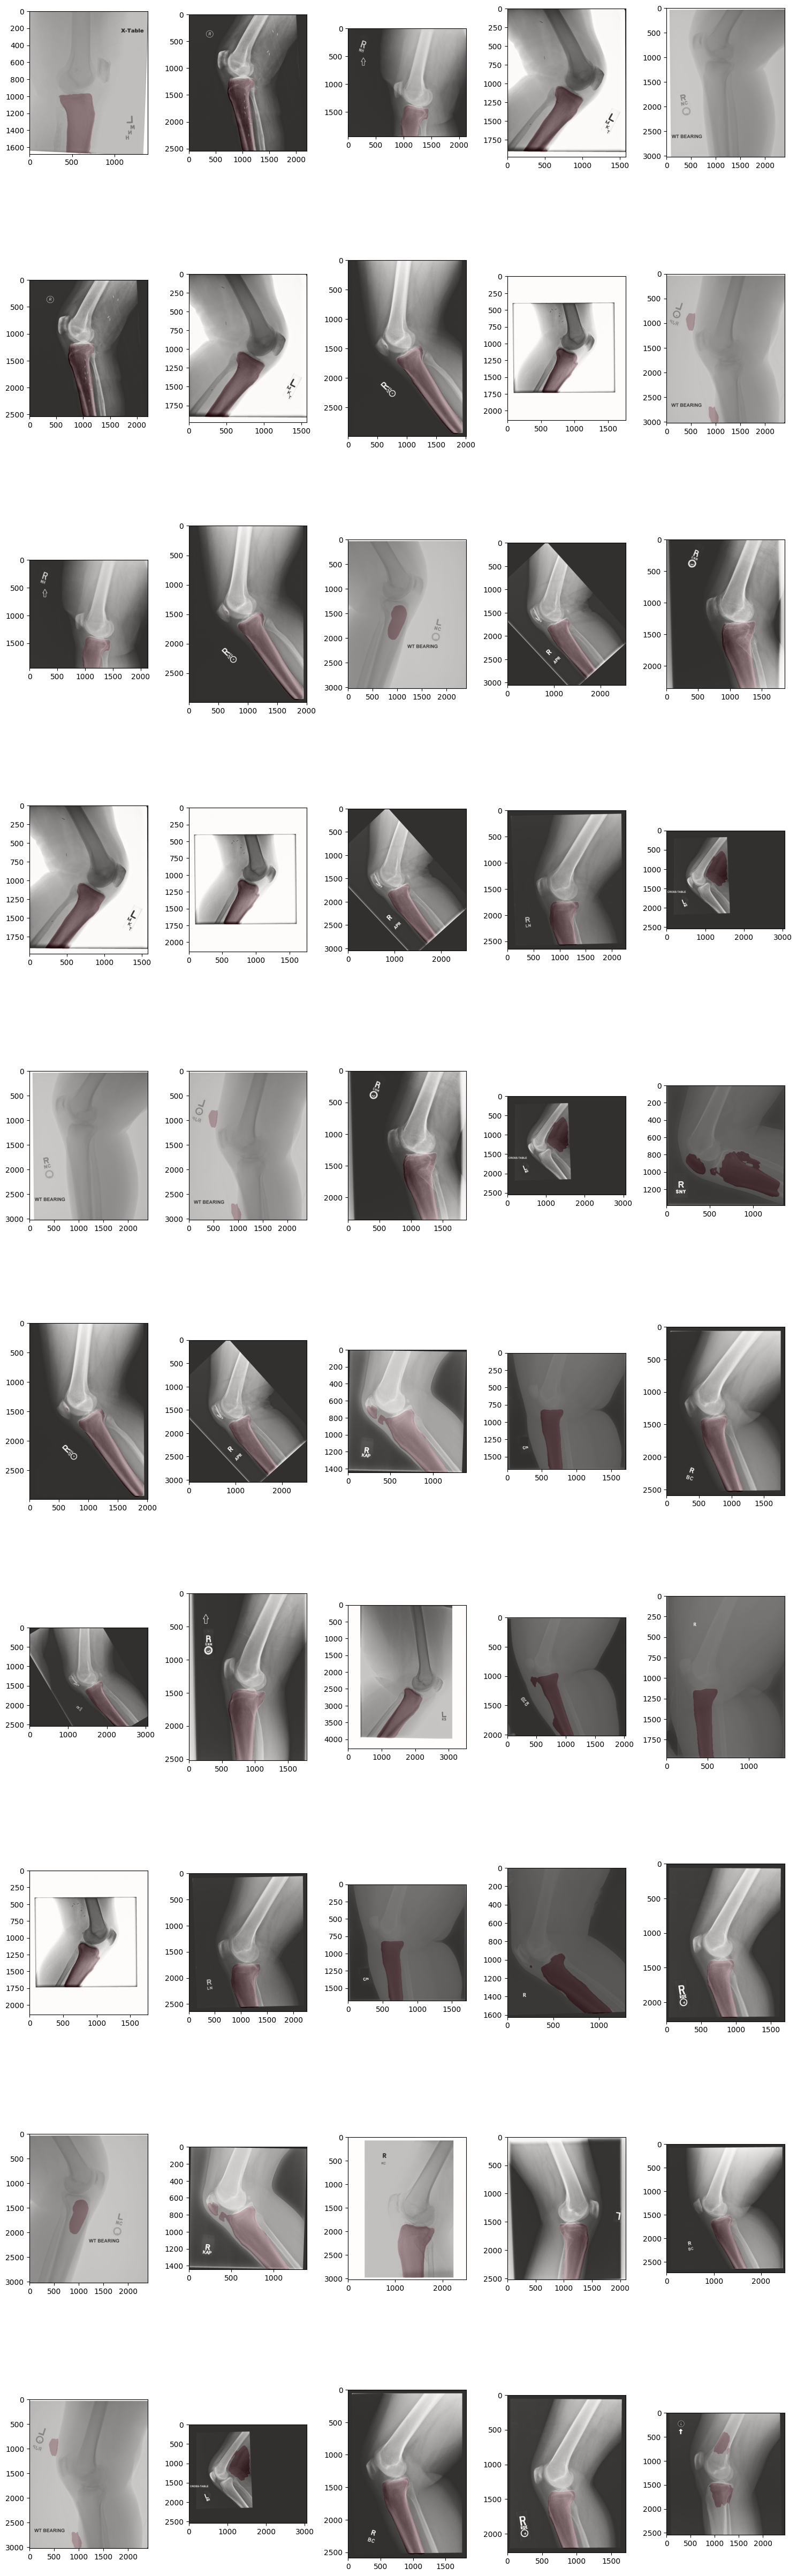

In [5]:


fig, ax = plt.subplots( round(len(dcm_paths) / 5), 5, figsize=(15, 50))

for i in range(round(len(dcm_paths) / 5)):
    for j in range(5):

        idx = (i+1)*(j+1) -1

        testimg = pyd.dcmread(dcm_paths[idx]).pixel_array
        testmask_read = sitk.ReadImage(mask_paths[idx])
        testmask = sitk.GetArrayFromImage(testmask_read)


        ax[i][j].imshow(testimg, 'gray')
        ax[i][j].imshow(testmask.squeeze(0), alpha=0.2, cmap='Reds')

plt.tight_layout()

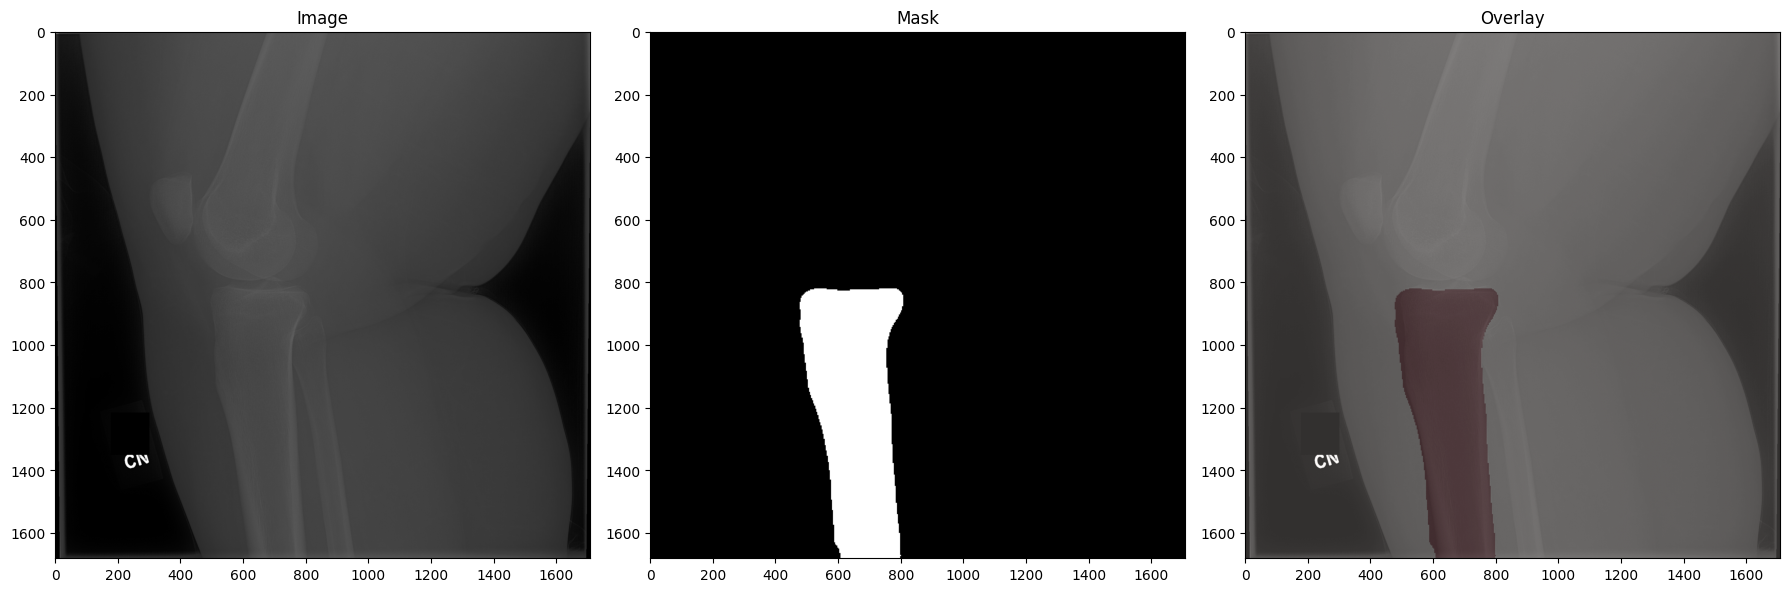

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(testimg, 'gray')
axes[0].set_title('Image')

axes[1].imshow(testmask.squeeze(0), 'gray')
axes[1].set_title('Mask')

axes[2].imshow(testimg, 'gray')
axes[2].imshow(testmask.squeeze(0), alpha=0.2, cmap='Reds')
axes[2].set_title('Overlay')

plt.tight_layout()
plt.show()



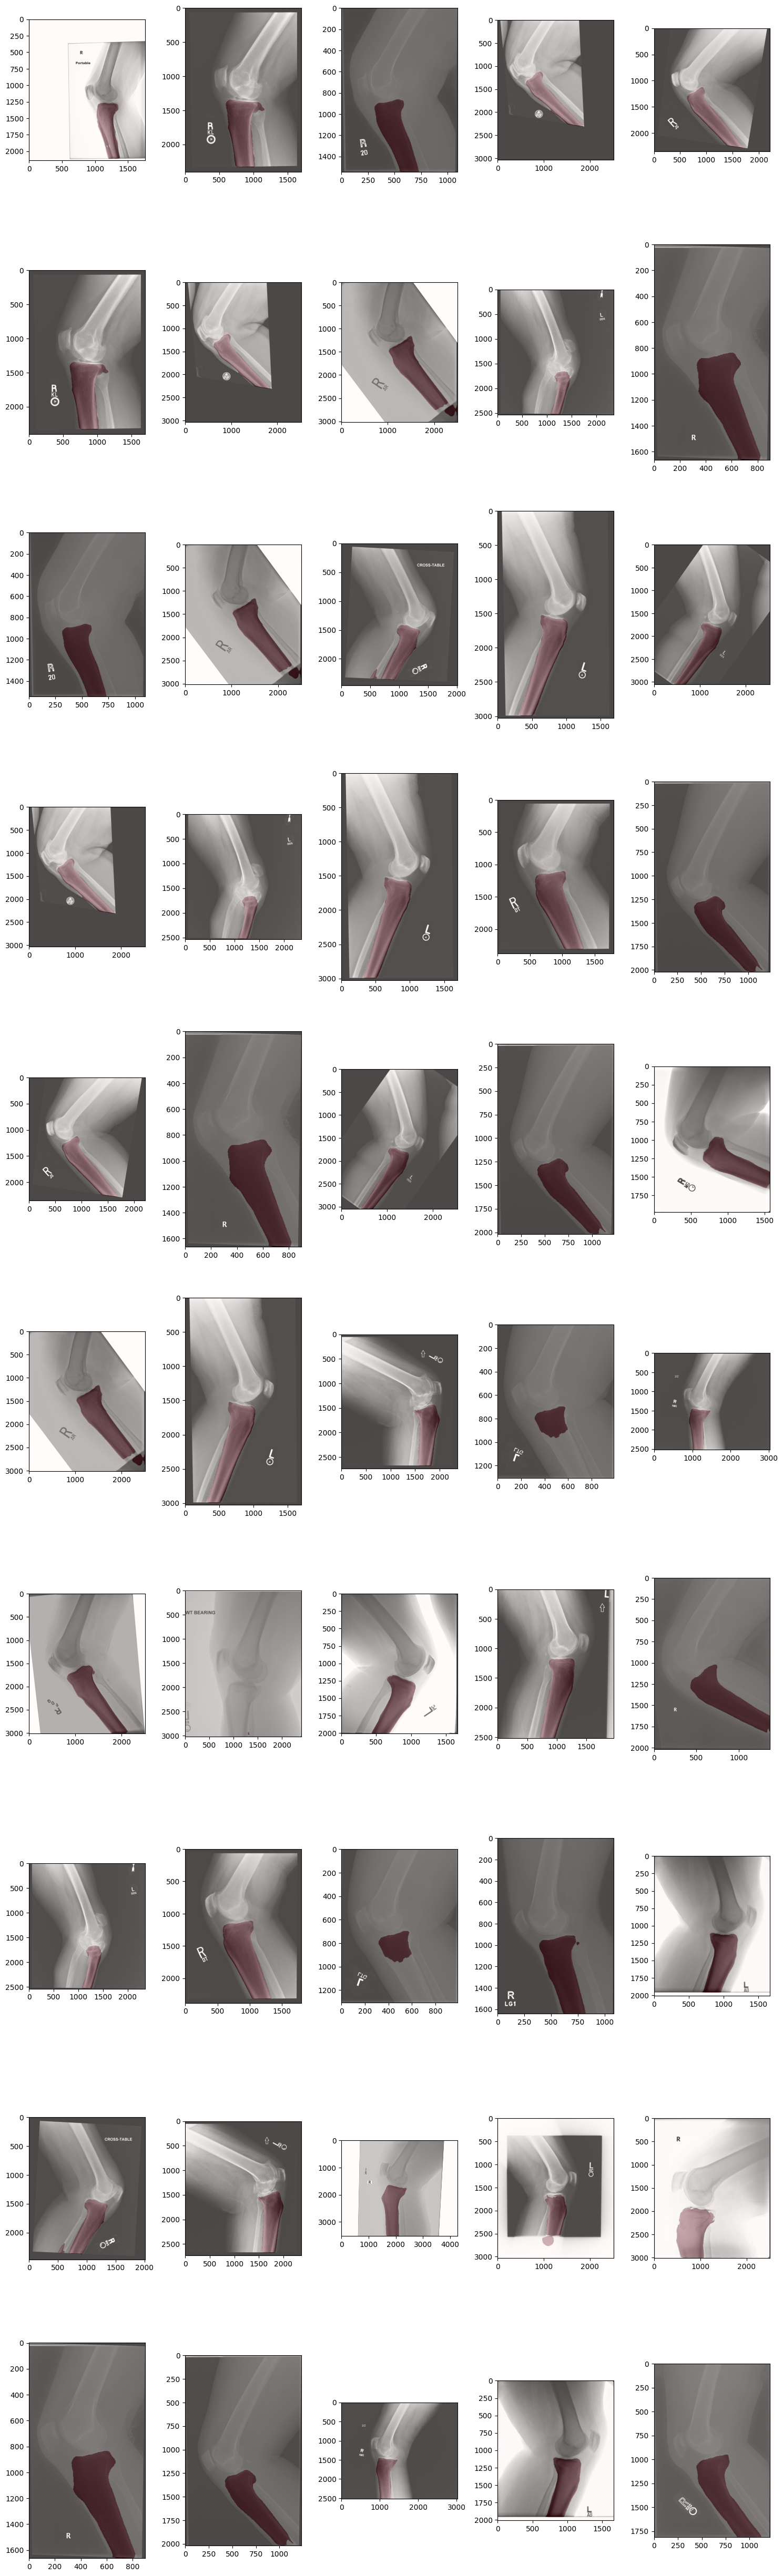

In [4]:
rows = int(len(dcm_paths) / 5)

fig, ax = plt.subplots( rows, 5, figsize=(15, 50))

for i in range(rows):
    for j in range(5):

        idx = (i+1)*(j+1) -1

        testimg = pyd.dcmread(dcm_paths[idx]).pixel_array
        testmask_read = sitk.ReadImage(mask_paths[idx])
        testmask = sitk.GetArrayFromImage(testmask_read)


        ax[i][j].imshow(testimg, 'gray')
        ax[i][j].imshow(testmask.squeeze(0), alpha=0.3, cmap='Reds')

plt.tight_layout()